# Récupération de Phase — Algorithme de Gerchberg–Saxton

Simulation numérique de la récupération de phase en optique par l'algorithme itératif de **Gerchberg–Saxton (G–S)**.

## Objectif

Reconstruire la phase d'un champ optique à partir de mesures d'intensité uniquement, et analyser :
- la **convergence** de l'algorithme
- l'influence des **discontinuités** de phase
- l'impact de la **phase initiale** (nulle vs. aléatoire)
- les **limites** fondamentales de la méthode

---

## Contexte physique

En optique, un champ électromagnétique est une grandeur complexe :
$$E(r) = A(r)\,e^{i\phi(r)}$$
Les capteurs (CCD, CMOS…) ne mesurent que l'**intensité** :
$$I(r) = |E(r)|^2$$
ce qui entraîne une **perte totale d'information sur la phase**.

## Algorithme de Gerchberg–Saxton

| Étape | Plan | Opération |
|-------|------|-----------|
| 0 | Objet | Initialisation : $x_0 = \|f\|\,e^{i\phi_0}$ |
| 1 | → Fourier | $X_k = \mathcal{F}(x_k)$ |
| 2 | Fourier | Contrainte module : $X'_k = \|F\|\,e^{i\psi_k}$ |
| 3 | → Objet | $x'_k = \mathcal{F}^{-1}(X'_k)$ |
| 4 | Objet | Contrainte amplitude : $x_{k+1} = \|f\|\,e^{i\phi_k}$ |
| 5 | — | Répéter jusqu'à convergence |

---

## 0. Configuration

In [5]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Chemin vers le module src/
sys.path.append(os.path.abspath('../scr'))
from gs_algorithm import (
    make_grid,
    construire_objet,
    construire_objet_gaussien,
    construire_objet_rampe,
    gerchberg_saxton,
    afficher_resultats,
    pearson_phase,
    rmse_phase,
    _colorbar_phase,
)

plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 12, 'axes.labelsize': 10})

# Dossier de sortie pour les figures
FIG_DIR = os.path.join('..', 'results', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Paramètres globaux
N         = 120
RAYON_EXT = 30
RAYON_INT = 15
N_ITER    = 500

X, Y, R = make_grid(N)
print(f'Grille : {N}×{N} px | Rayon ext : {RAYON_EXT} px | Rayon int : {RAYON_INT} px | Itérations : {N_ITER}')

Grille : 120×120 px | Rayon ext : 30 px | Rayon int : 15 px | Itérations : 500


## 1. Construction de l'objet de référence

L'objet est un **disque binaire** (amplitude 1 dans le cercle, 0 en dehors) avec deux zones de phase distinctes.

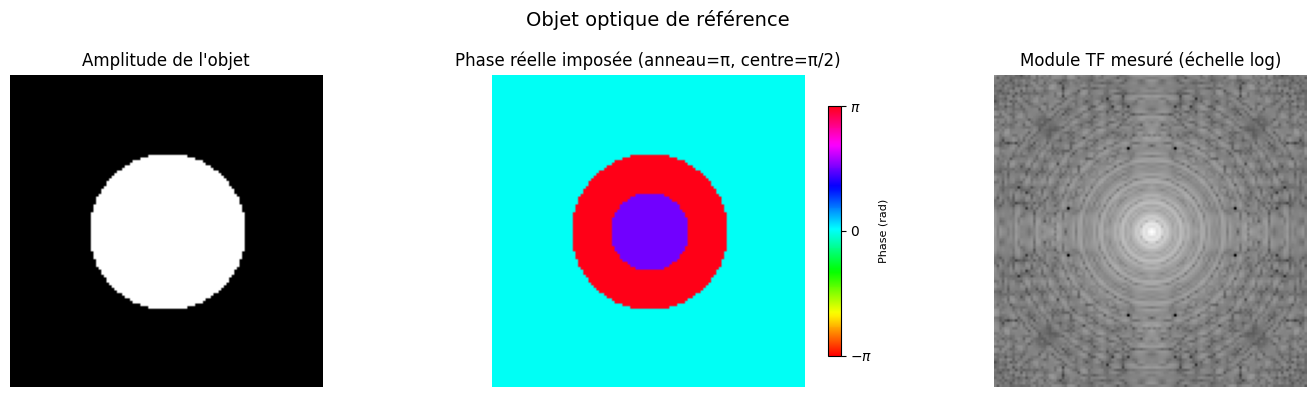

In [6]:
amp_ref, champ_ref = construire_objet(N, RAYON_EXT, RAYON_INT,
                                       phase_anneau=np.pi,
                                       phase_centre=np.pi / 2)
TF_ref = np.abs(np.fft.fftshift(np.fft.fft2(champ_ref)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(amp_ref, cmap='gray')
axes[0].set_title("Amplitude de l'objet")
axes[0].axis('off')

im1 = axes[1].imshow(np.angle(champ_ref), cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[1].set_title('Phase réelle imposée (anneau=π, centre=π/2)')
axes[1].axis('off')
_colorbar_phase(fig, im1, axes[1])

axes[2].imshow(np.log10(TF_ref + 1e-9), cmap='gray')
axes[2].set_title('Module TF mesuré (échelle log)')
axes[2].axis('off')

plt.suptitle('Objet optique de référence', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '00_objet_reference.png'), dpi=150, bbox_inches='tight')
plt.show()

## 2. Phase initiale : nulle vs. aléatoire

L'algorithme G–S est sensible à la phase initiale $\phi_0$. On compare ici deux stratégies :

- **Phase nulle** : $\phi_0 = 0$ partout — démarrage déterministe
- **Phase aléatoire** : $\phi_0 \sim \mathcal{U}[0, 2\pi)$ — explore mieux l'espace des solutions

La corrélation de Pearson et le RMSE permettent de comparer quantitativement les reconstructions.

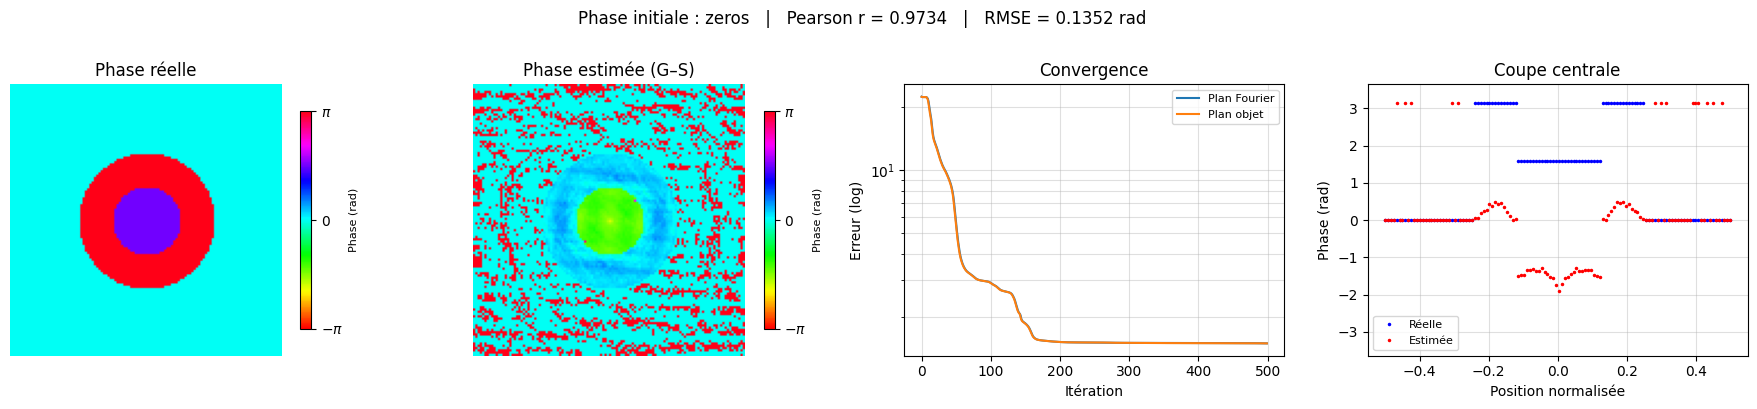

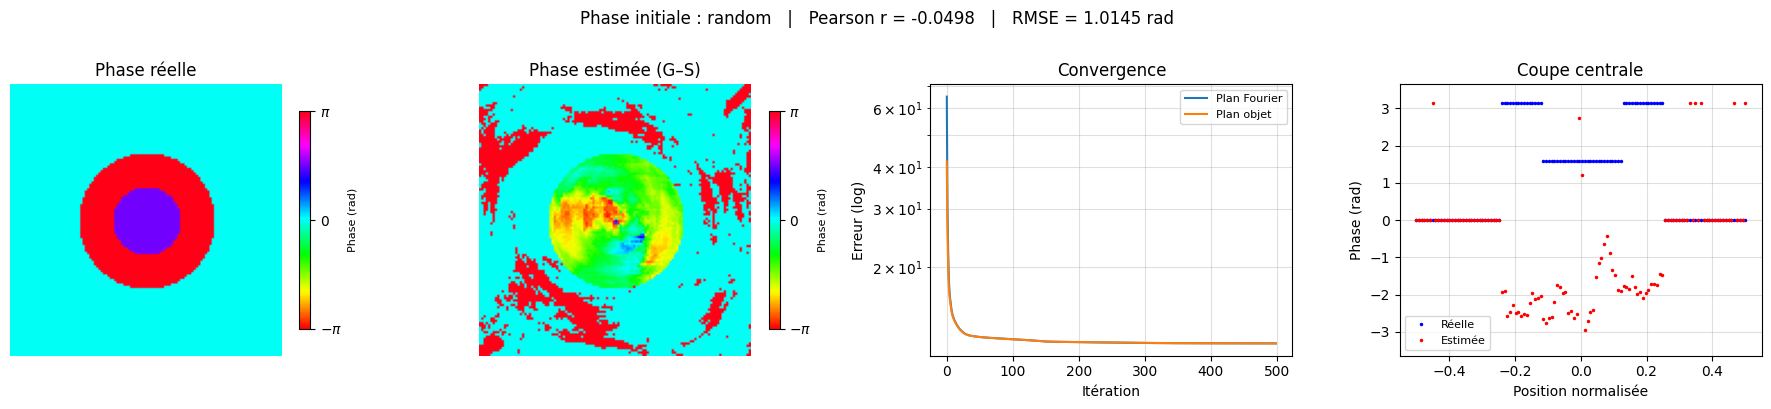

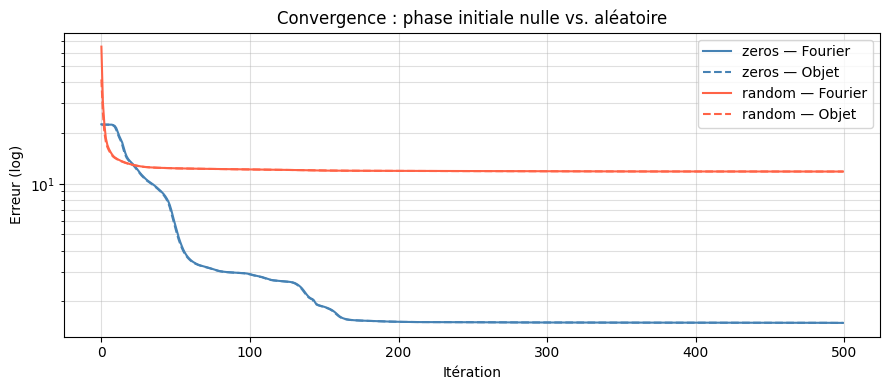


── Métriques de qualité (masque = disque) ──
Init          Pearson r   RMSE (rad)
zeros            0.9734       0.1352
random          -0.0498       1.0145


In [7]:
masque = R < RAYON_EXT   # on évalue la qualité uniquement dans le disque

resultats_init = {}
for init in ['zeros', 'random']:
    champ_est, E_f, E_o = gerchberg_saxton(amp_ref, TF_ref,
                                            n_iter=N_ITER,
                                            phase_init=init)
    r, rms = afficher_resultats(
        np.angle(champ_ref), champ_est, E_f, E_o,
        titre=f'Phase initiale : {init}',
        masque=masque,
        save_path=os.path.join(FIG_DIR, f'01_init_{init}.png')
    )
    resultats_init[init] = {'r': r, 'rmse': rms, 'E_f': E_f, 'E_o': E_o}

# Comparaison des courbes de convergence
fig, ax = plt.subplots(figsize=(9, 4))
for init, col in [('zeros', 'steelblue'), ('random', 'tomato')]:
    ax.semilogy(resultats_init[init]['E_f'], color=col,
                linestyle='-',  linewidth=1.5, label=f'{init} — Fourier')
    ax.semilogy(resultats_init[init]['E_o'], color=col,
                linestyle='--', linewidth=1.5, label=f'{init} — Objet')
ax.set_xlabel('Itération')
ax.set_ylabel('Erreur (log)')
ax.set_title('Convergence : phase initiale nulle vs. aléatoire')
ax.legend()
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_convergence_init.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n── Métriques de qualité (masque = disque) ──")
print(f"{'Init':<10} {'Pearson r':>12} {'RMSE (rad)':>12}")
for init, m in resultats_init.items():
    print(f"{init:<10} {m['r']:>12.4f} {m['rmse']:>12.4f}")

## 3. Phases discontinues

On augmente progressivement le saut de phase entre l'anneau et le centre pour caractériser les limites de l'algorithme face aux **discontinuités**.

/opt/anaconda3/envs/ml/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


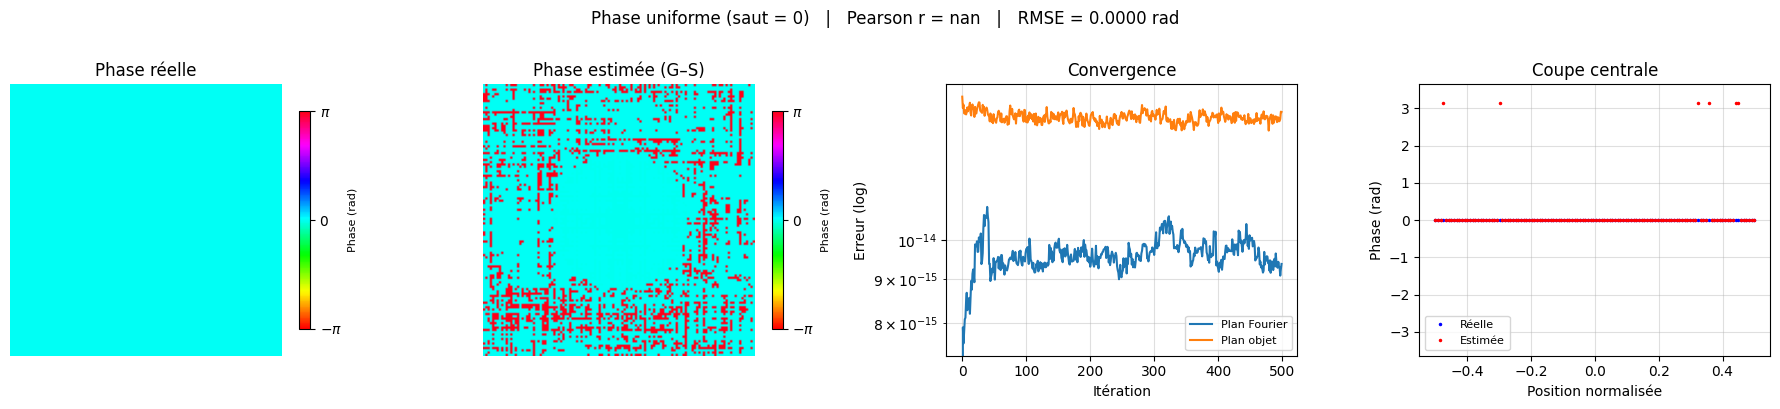

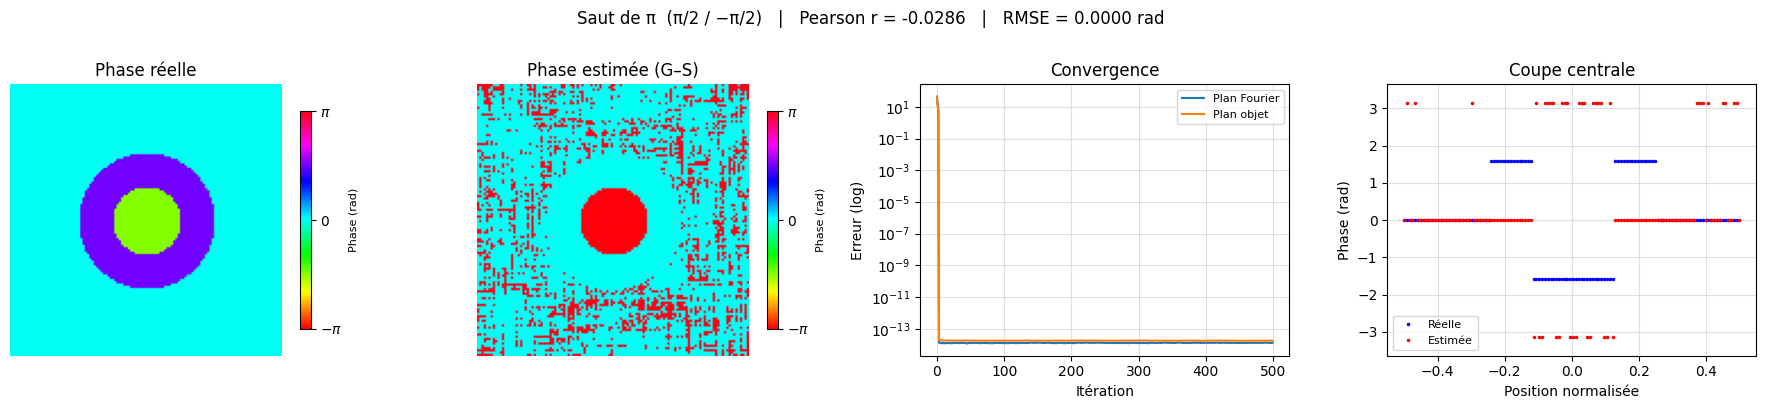

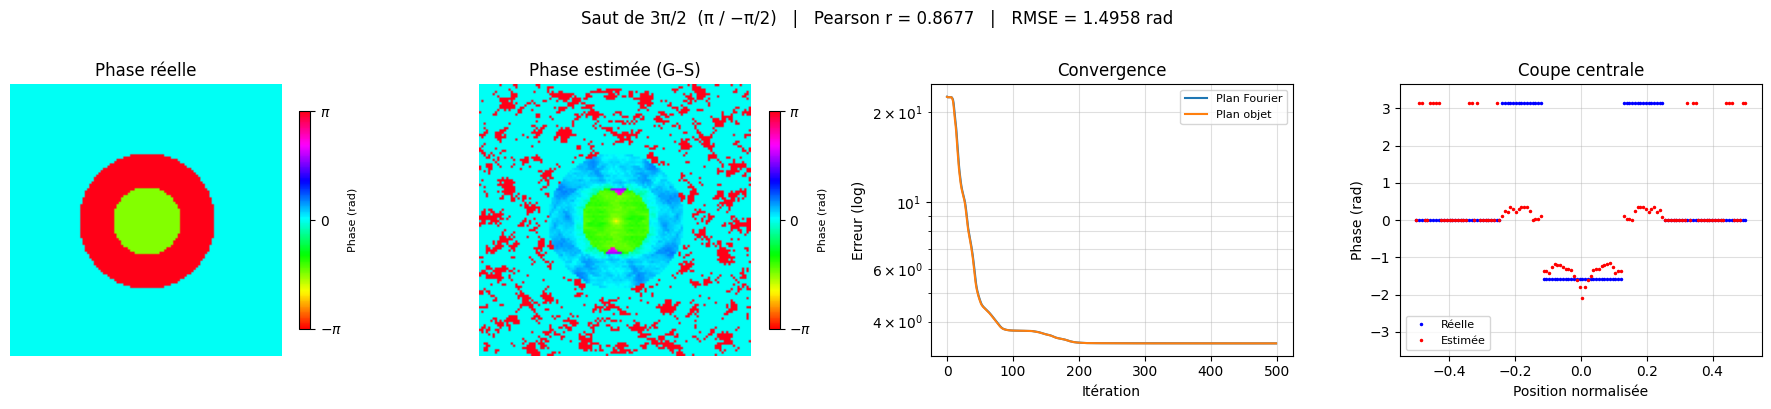

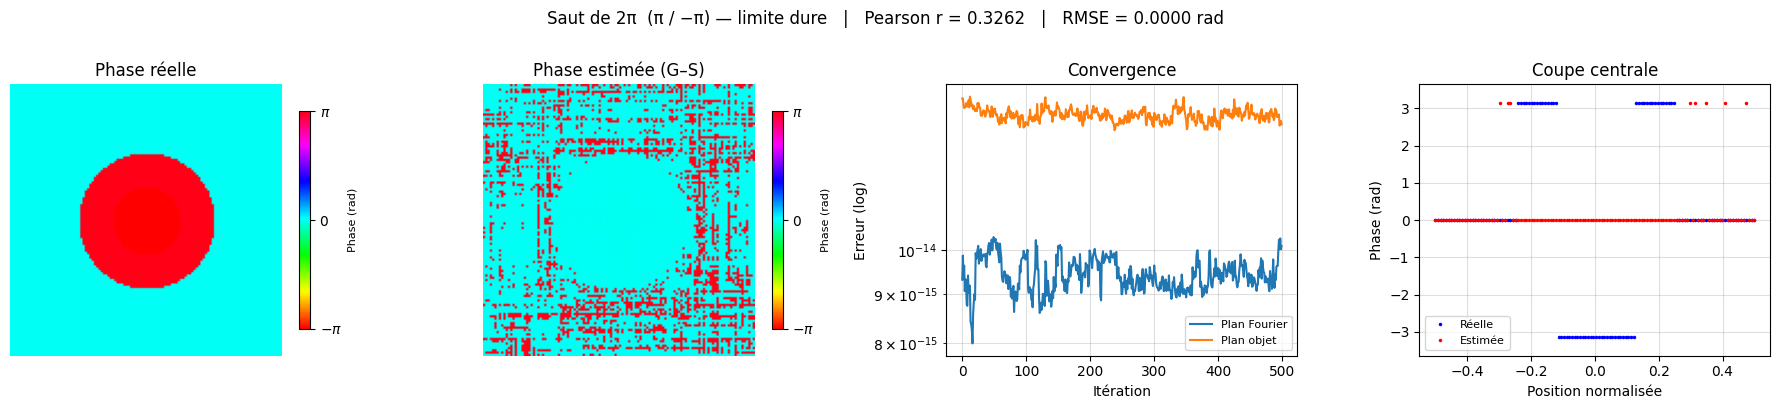

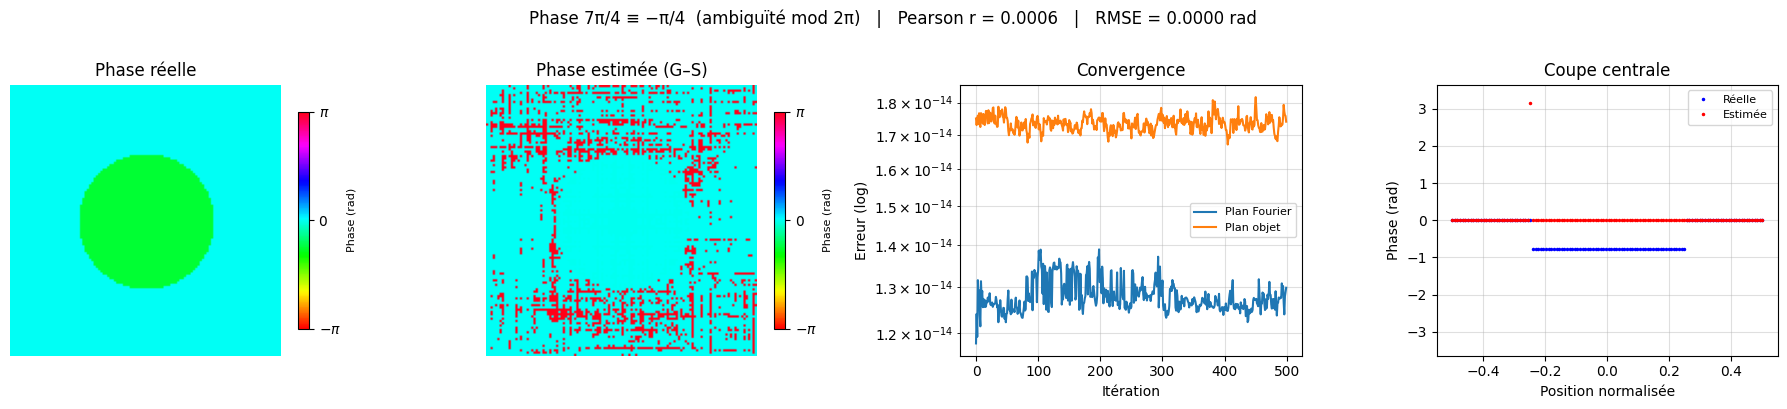


── Bilan phases discontinues ──
Cas                                     φ_anneau/π  φ_centre/π  Pearson r     RMSE
Phase uniforme (saut = 0)                     0.00        0.00        nan   0.0000
Saut de π  (π/2 / −π/2)                       0.50       -0.50    -0.0286   0.0000
Saut de 3π/2  (π / −π/2)                      1.00       -0.50     0.8677   1.4958
Saut de 2π  (π / −π) — limite dure            1.00       -1.00     0.3262   0.0000
Phase 7π/4 ≡ −π/4  (ambiguïté mod 2π)         1.75        1.75     0.0006   0.0000


In [8]:
cas_discontinus = [
    (0,            0,           'cas1_uniforme',     'Phase uniforme (saut = 0)'),
    (np.pi/2,     -np.pi/2,    'cas2_saut_pi',       'Saut de π  (π/2 / −π/2)'),
    (np.pi,       -np.pi/2,    'cas3_saut_3pi2',     'Saut de 3π/2  (π / −π/2)'),
    (np.pi,       -np.pi,      'cas4_saut_2pi',      'Saut de 2π  (π / −π) — limite dure'),
    (7*np.pi/4,    7*np.pi/4,  'cas5_ambiguite',     'Phase 7π/4 ≡ −π/4  (ambiguïté mod 2π)'),
]

tableau = []
for pa, pc, fname, label in cas_discontinus:
    amp, champ = construire_objet(N, RAYON_EXT, RAYON_INT, pa, pc)
    TF_mes     = np.abs(np.fft.fftshift(np.fft.fft2(champ)))
    champ_est, E_f, E_o = gerchberg_saxton(amp, TF_mes, n_iter=N_ITER)
    r, rms = afficher_resultats(
        np.angle(champ), champ_est, E_f, E_o,
        titre=label, masque=R < RAYON_EXT,
        save_path=os.path.join(FIG_DIR, f'02_{fname}.png')
    )
    tableau.append((label, pa/np.pi, pc/np.pi, r, rms))

print("\n── Bilan phases discontinues ──")
print(f"{'Cas':<38} {'φ_anneau/π':>11} {'φ_centre/π':>11} {'Pearson r':>10} {'RMSE':>8}")
for row in tableau:
    print(f"{row[0]:<38} {row[1]:>11.2f} {row[2]:>11.2f} {row[3]:>10.4f} {row[4]:>8.4f}")

## 4. Phase gaussienne

Au lieu de phases constantes par zones, on impose une **distribution gaussienne radiale** :
$$\phi(r) = A\,\exp\!\left(-\frac{(r - r_0)^2}{\sigma^2}\right)$$
Ce cas est plus réaliste (aberrations optiques, front d'onde déformé) et constitue un test plus exigeant pour l'algorithme.

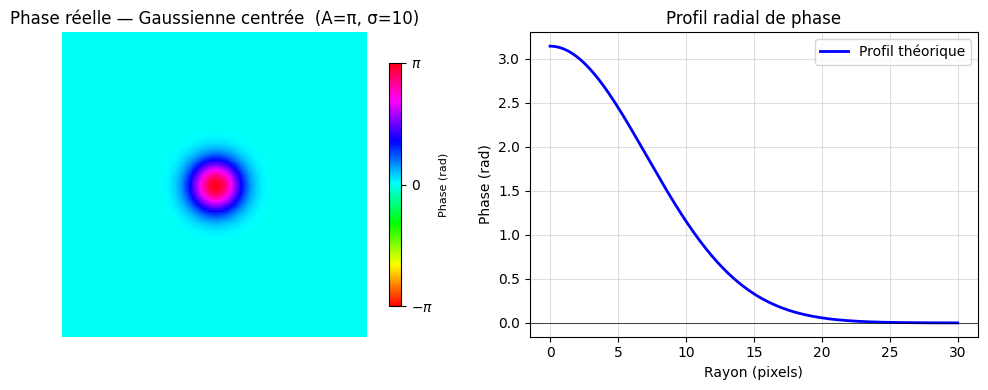

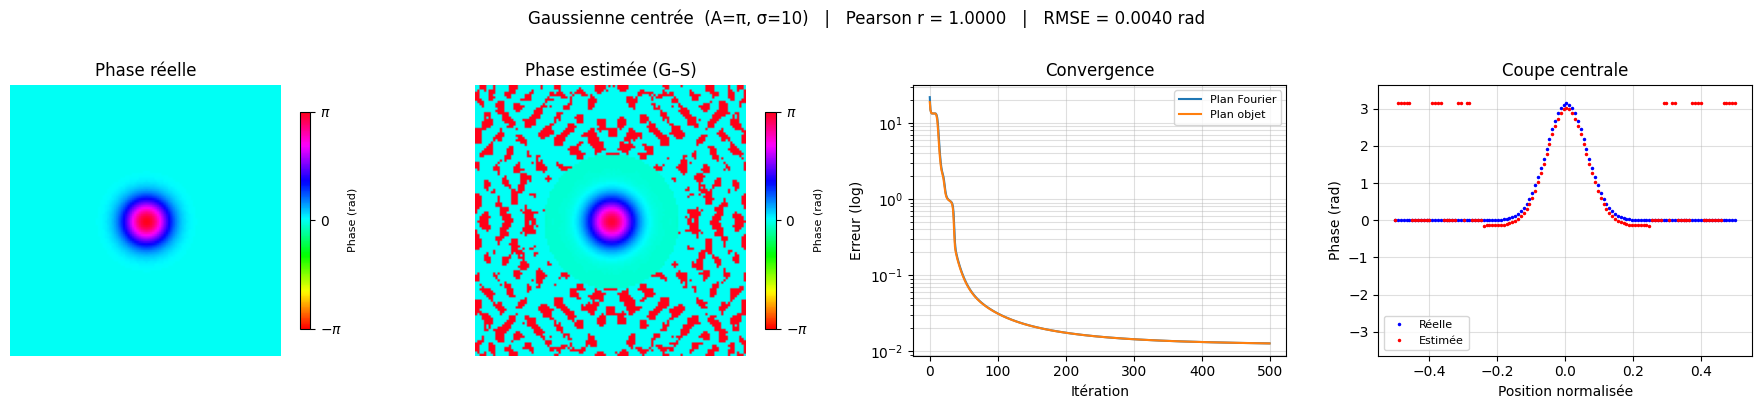

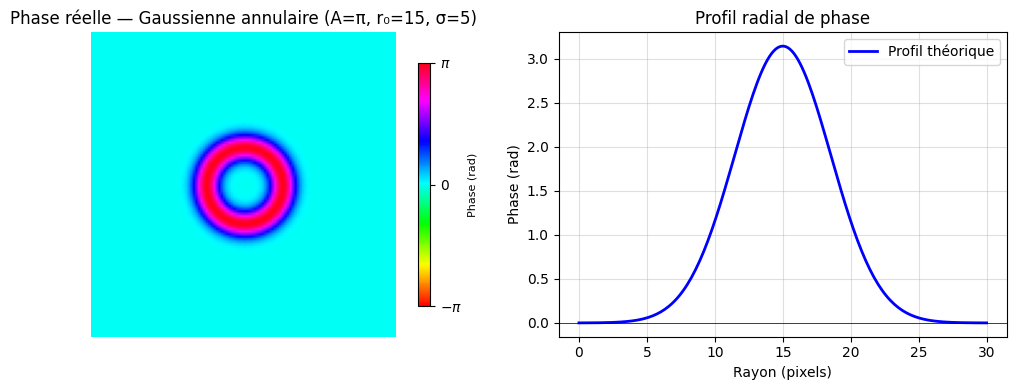

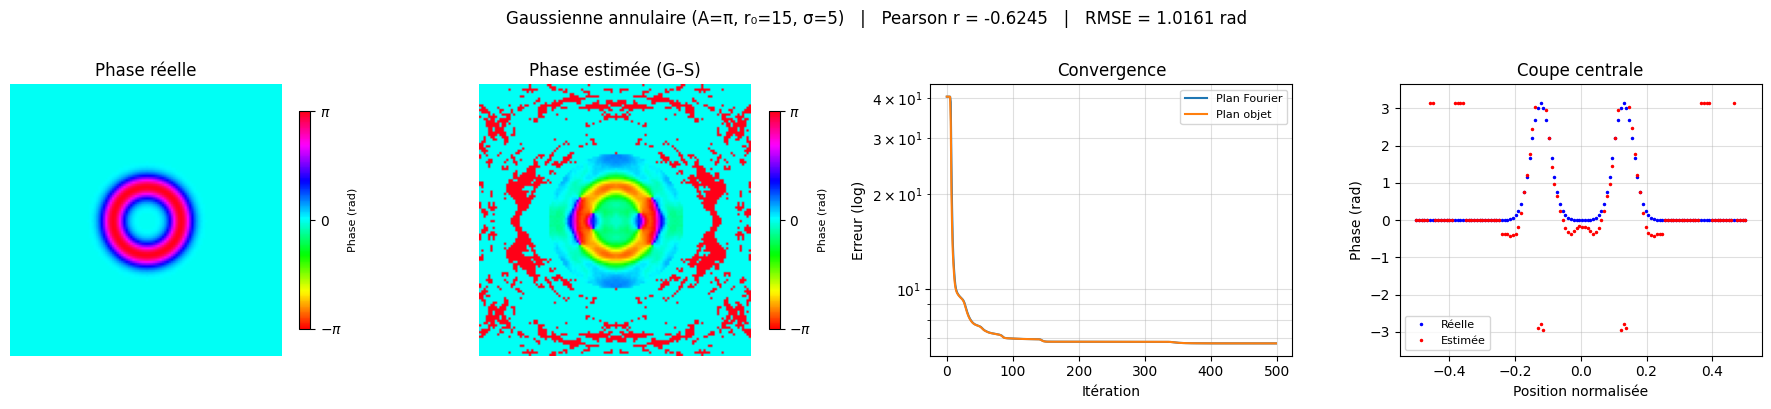

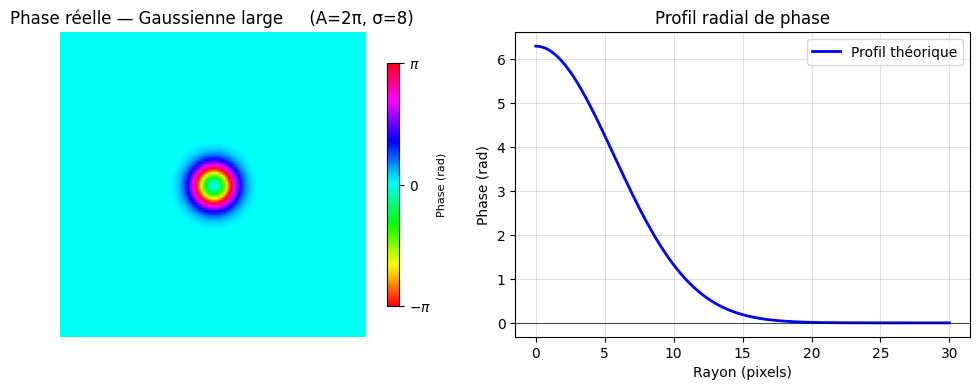

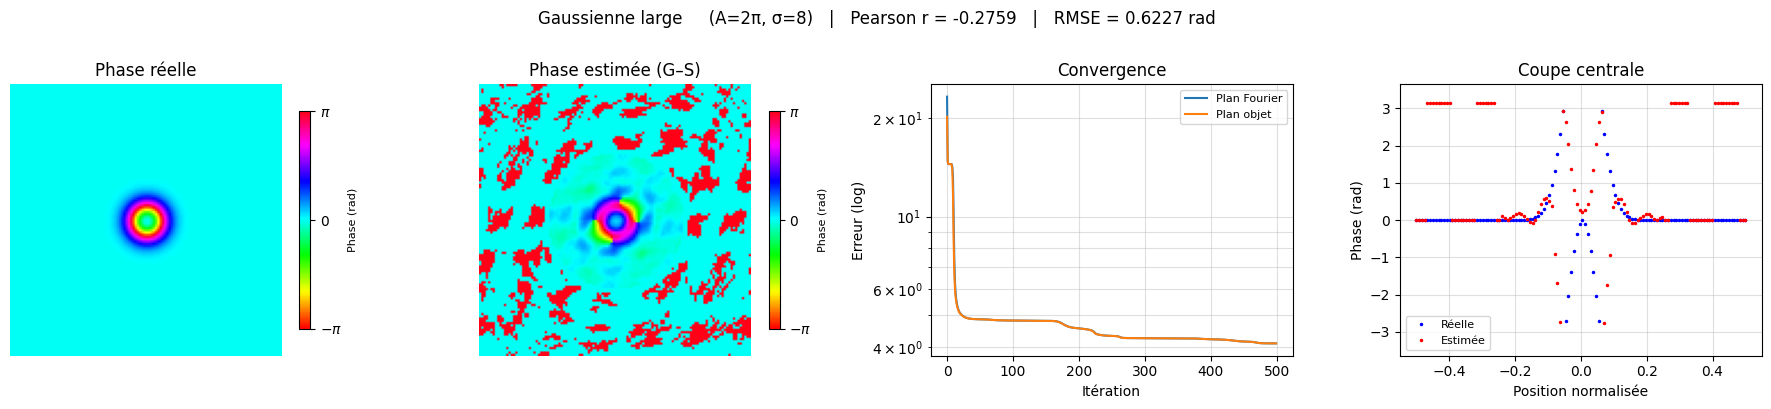

In [9]:
cas_gaussiens = [
    dict(A=np.pi,     r0=0.0,  sigma=10.0, label='Gaussienne centrée  (A=π, σ=10)',     fname='gaussienne_centree'),
    dict(A=np.pi,     r0=15.0, sigma=5.0,  label='Gaussienne annulaire (A=π, r₀=15, σ=5)', fname='gaussienne_annulaire'),
    dict(A=2*np.pi,   r0=0.0,  sigma=8.0,  label='Gaussienne large     (A=2π, σ=8)',    fname='gaussienne_large'),
]

for cfg in cas_gaussiens:
    amp, champ = construire_objet_gaussien(N, RAYON_EXT,
                                            A=cfg['A'], r0=cfg['r0'], sigma=cfg['sigma'])
    TF_mes     = np.abs(np.fft.fftshift(np.fft.fft2(champ)))
    champ_est, E_f, E_o = gerchberg_saxton(amp, TF_mes, n_iter=N_ITER)

    # Visualisation du profil radial de phase
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im = axes[0].imshow(np.angle(champ), cmap='hsv', vmin=-np.pi, vmax=np.pi)
    axes[0].set_title(f"Phase réelle — {cfg['label']}")
    axes[0].axis('off')
    _colorbar_phase(fig, im, axes[0])

    r_vals = np.linspace(0, RAYON_EXT, 200)
    phi_th = cfg['A'] * np.exp(-((r_vals - cfg['r0'])**2) / cfg['sigma']**2)
    axes[1].plot(r_vals, phi_th, 'b-', linewidth=2, label='Profil théorique')
    axes[1].set_xlabel('Rayon (pixels)')
    axes[1].set_ylabel('Phase (rad)')
    axes[1].set_title('Profil radial de phase')
    axes[1].axhline(0, color='k', linewidth=0.5)
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"03_{cfg['fname']}_profil.png"), dpi=150, bbox_inches='tight')
    plt.show()

    afficher_resultats(
        np.angle(champ), champ_est, E_f, E_o,
        titre=cfg['label'], masque=R < RAYON_EXT,
        save_path=os.path.join(FIG_DIR, f"03_{cfg['fname']}_reconstruction.png")
    )

## 5. Rampe de phase (onde plane inclinée)

Une onde plane inclinée de vecteur $(k_x, k_y)$ s'écrit :
$$E(x,y) = A(x,y)\,e^{i(k_x x + k_y y)}$$
Dans le plan de Fourier, cela se traduit par un **décalage du pic d'intensité**. On vérifie ce comportement et on teste la reconstruction.

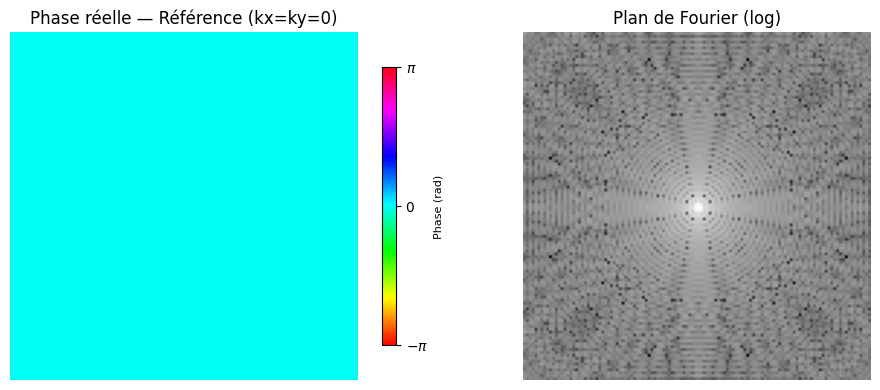

/opt/anaconda3/envs/ml/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


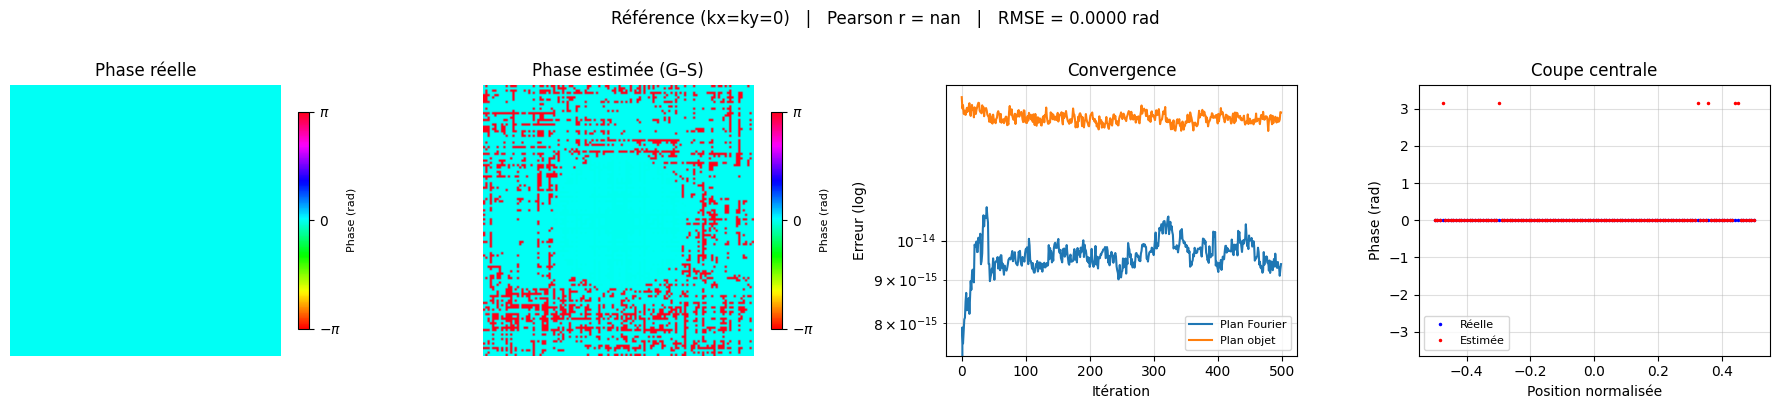

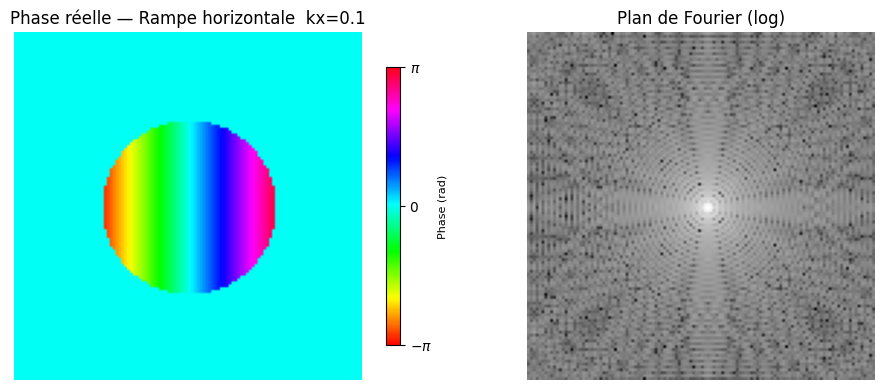

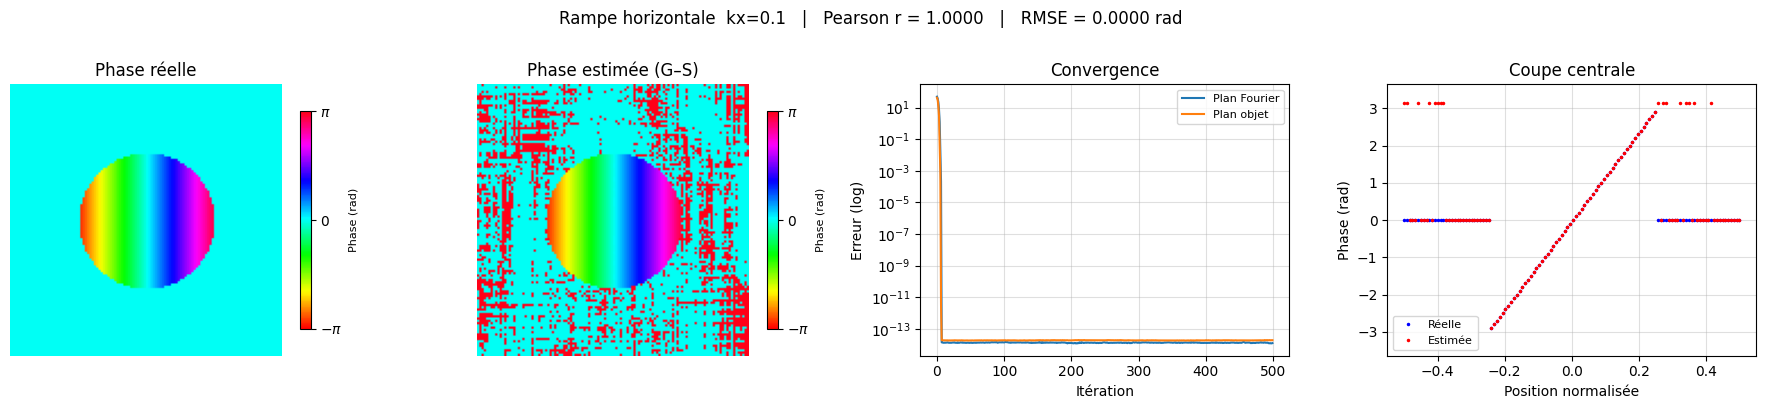

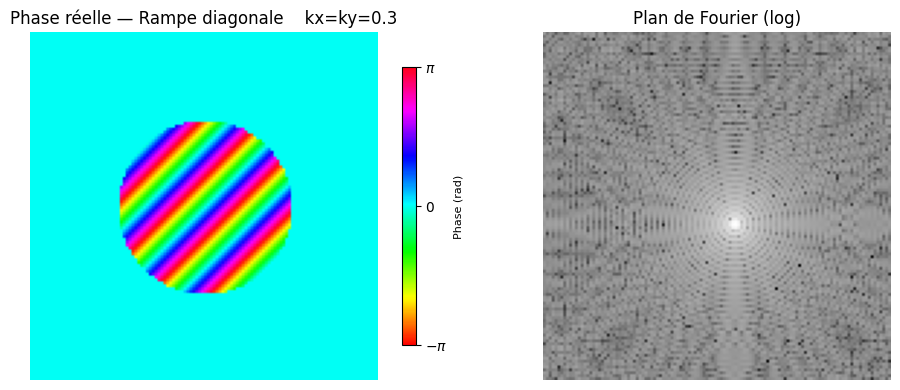

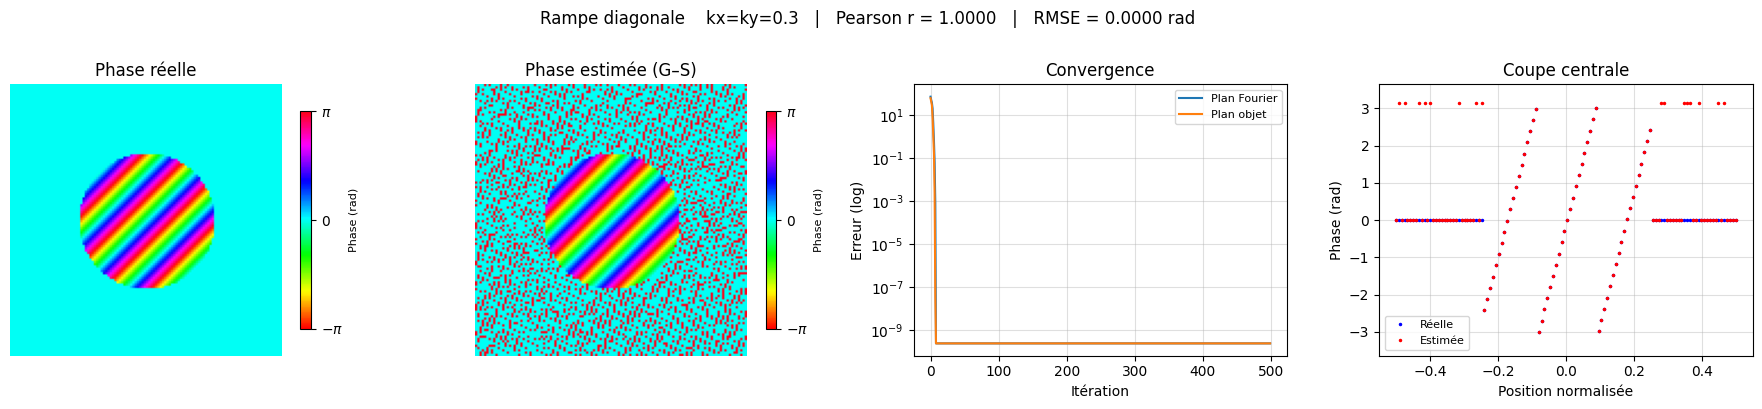

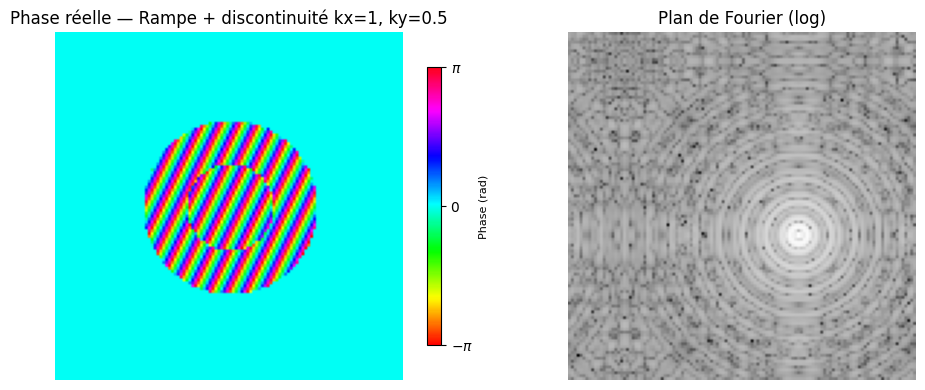

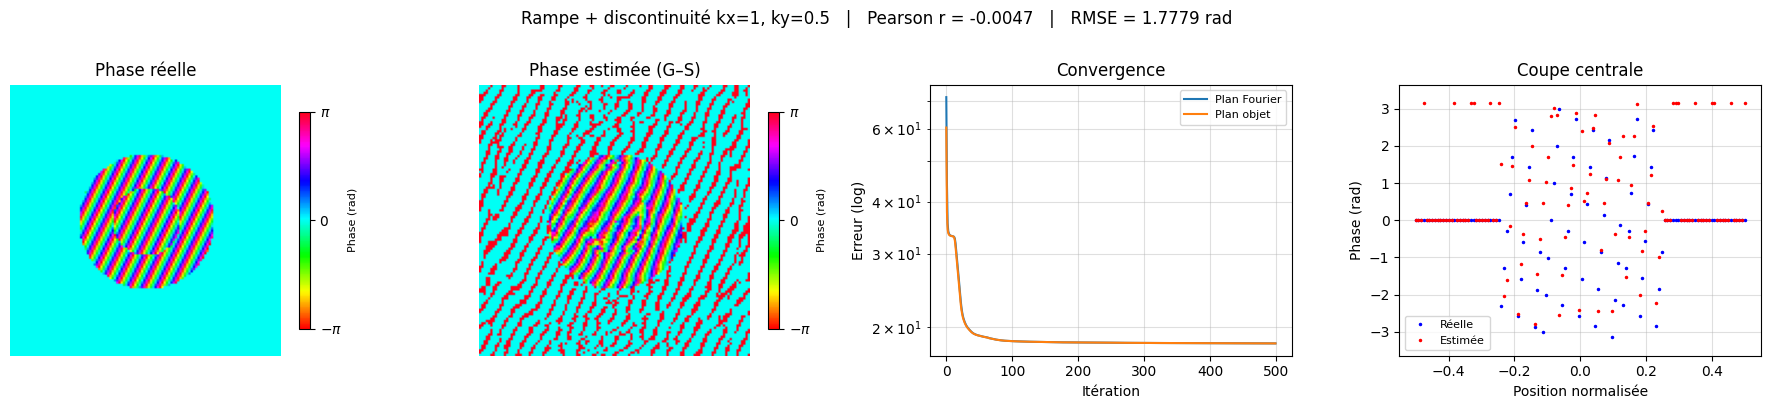

In [10]:
cas_rampes = [
    (0,        0,        0.0, 0.0, 'rampe_ref',      'Référence (kx=ky=0)'),
    (0,        0,        0.1, 0.0, 'rampe_horiz',    'Rampe horizontale  kx=0.1'),
    (0,        0,        0.3, 0.3, 'rampe_diag',     'Rampe diagonale    kx=ky=0.3'),
    (np.pi/2, -np.pi/2,  1.0, 0.5, 'rampe_complexe', 'Rampe + discontinuité kx=1, ky=0.5'),
]

for pa, pc, kx, ky, fname, label in cas_rampes:
    amp, champ = construire_objet_rampe(N, RAYON_EXT, RAYON_INT, pa, pc, kx, ky)
    TF_mes     = np.abs(np.fft.fftshift(np.fft.fft2(champ)))

    # Plan de Fourier
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im0 = axes[0].imshow(np.angle(champ), cmap='hsv', vmin=-np.pi, vmax=np.pi)
    axes[0].set_title(f'Phase réelle — {label}')
    axes[0].axis('off')
    _colorbar_phase(fig, im0, axes[0])
    axes[1].imshow(np.log10(TF_mes + 1e-9), cmap='gray')
    axes[1].set_title('Plan de Fourier (log)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f'05_{fname}_fourier.png'), dpi=150, bbox_inches='tight')
    plt.show()

    champ_est, E_f, E_o = gerchberg_saxton(amp, TF_mes, n_iter=N_ITER)
    afficher_resultats(
        np.angle(champ), champ_est, E_f, E_o,
        titre=label, masque=R < RAYON_EXT,
        save_path=os.path.join(FIG_DIR, f'05_{fname}_reconstruction.png')
    )

## 6. Tableau de synthèse des métriques

Récapitulatif de tous les cas testés avec la corrélation de Pearson $r$ et le RMSE.

In [11]:
tous_les_cas = [
    # (label, amplitude, champ_reel)
]

# On reconstruit tous les cas pour le tableau final
specs = [
    ('Phase nulle (init zeros)',    lambda: construire_objet(N, RAYON_EXT, RAYON_INT, np.pi, np.pi/2), 'zeros'),
    ('Phase nulle (init random)',   lambda: construire_objet(N, RAYON_EXT, RAYON_INT, np.pi, np.pi/2), 'random'),
    ('Saut 0',                      lambda: construire_objet(N, RAYON_EXT, RAYON_INT, 0, 0),            'zeros'),
    ('Saut π',                      lambda: construire_objet(N, RAYON_EXT, RAYON_INT, np.pi/2, -np.pi/2), 'zeros'),
    ('Saut 3π/2',                   lambda: construire_objet(N, RAYON_EXT, RAYON_INT, np.pi, -np.pi/2),  'zeros'),
    ('Ambiguïté mod 2π',            lambda: construire_objet(N, RAYON_EXT, RAYON_INT, 7*np.pi/4, 7*np.pi/4), 'zeros'),
    ('Gaussienne centrée',          lambda: construire_objet_gaussien(N, RAYON_EXT, A=np.pi, r0=0, sigma=10), 'zeros'),
    ('Gaussienne annulaire',        lambda: construire_objet_gaussien(N, RAYON_EXT, A=np.pi, r0=15, sigma=5), 'zeros'),
    ('Rampe horizontale',           lambda: construire_objet_rampe(N, RAYON_EXT, RAYON_INT, 0, 0, 0.1, 0),   'zeros'),
    ('Rampe diagonale',             lambda: construire_objet_rampe(N, RAYON_EXT, RAYON_INT, 0, 0, 0.3, 0.3), 'zeros'),
    ('Rampe + discontinuité',       lambda: construire_objet_rampe(N, RAYON_EXT, RAYON_INT, np.pi/2, -np.pi/2, 1.0, 0.5), 'zeros'),
]

print(f"{'Cas':<30} {'Pearson r':>10} {'RMSE (rad)':>12} {'Qualité':>10}")
print('─' * 65)
for label, builder, init in specs:
    amp, champ = builder()
    TF_mes = np.abs(np.fft.fftshift(np.fft.fft2(champ)))
    champ_est, _, _ = gerchberg_saxton(amp, TF_mes, n_iter=N_ITER, phase_init=init)
    r   = pearson_phase(np.angle(champ), np.angle(champ_est), masque=R < RAYON_EXT)
    rms = rmse_phase(np.angle(champ),   np.angle(champ_est), masque=R < RAYON_EXT)
    qualite = 'Bon' if r > 0.95 else ('Moyen' if r > 0.7 else 'Échec')
    print(f"{label:<30} {r:>10.4f} {rms:>12.4f} {qualite:>10}")

Cas                             Pearson r   RMSE (rad)    Qualité
─────────────────────────────────────────────────────────────────
Phase nulle (init zeros)           0.9734       0.1352        Bon
Phase nulle (init random)         -0.1543       1.0512      Échec


/opt/anaconda3/envs/ml/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Saut 0                                nan       0.0000      Échec
Saut π                            -0.0286       0.0000      Échec
Saut 3π/2                          0.8677       1.4958      Moyen
Ambiguïté mod 2π                   0.0006       0.0000      Échec
Gaussienne centrée                 1.0000       0.0040        Bon
Gaussienne annulaire              -0.6245       1.0161      Échec
Rampe horizontale                  1.0000       0.0000        Bon
Rampe diagonale                    1.0000       0.0000        Bon
Rampe + discontinuité             -0.0047       1.7779      Échec


## 7. Analyse des limites

Les simulations mettent en évidence six limites fondamentales de l'algorithme G–S.

### 7.1 Bruit numérique dans les zones d'amplitude nulle

Là où l'amplitude vaut zéro, la phase est **physiquement indéfinie**. Numériquement, la FFT ne produit jamais exactement zéro, donc on calcule l'argument de nombres très petits → phase instable (bruit apparent). Ce n'est pas un défaut de l'algorithme, c'est une limite numérique. **Solution** : utiliser un masque pour ignorer ces zones lors de l'évaluation.

### 7.2 Ambiguïté modulo 2π

L'intensité est invariante par translation globale de phase et par conjugaison complexe :
$$|\mathcal{F}[e^{i(\phi+c)}f]|= |\mathcal{F}[f]| \quad \forall\, c \in \mathbb{R}$$
On ne peut donc reconstruire que la **phase relative**, jamais la phase absolue. De plus, toute phase $\phi$ est indiscernable de $\phi + 2\pi k$.

### 7.3 Stagnation dans les minima locaux

Le problème de récupération de phase est **non-convexe** : l'algorithme peut converger vers une solution sous-optimale même avec de nombreuses itérations. La phase initiale aléatoire peut aider mais ne garantit pas la convergence vers le minimum global.

### 7.4 Repliement de phase (aliasing)

Quand la variation de phase entre deux pixels adjacents dépasse $\pi$, le problème d'échantillonnage crée un **repliement** que l'algorithme interprète comme du bruit. C'est ce qui explique l'échec dans le cas rampe + discontinuité.

### 7.5 Vortex de phase

Autour d'un point où l'amplitude s'annule, la phase peut former une **singularité spiralée** (vortex de phase). Ces structures ne sont pas des erreurs de reconstruction mais des solutions physiquement valides du problème.

### 7.6 Perte de la phase absolue

Plusieurs transformations laissent l'intensité invariante : ajout d'une constante, conjugaison, ajout d'une rampe. L'algorithme ne peut donc pas distinguer le champ original de ces transformées.

## 8. Conclusion

L'algorithme de Gerchberg–Saxton permet de récupérer la phase dans de nombreux cas pratiques, mais ses limites sont inhérentes à la physique du problème :

| Limite | Contournable ? | Piste |
|--------|---------------|-------|
| Ambiguïté mod 2π | Non (physique) | — |
| Perte de phase absolue | Non (physique) | — |
| Minima locaux | Partiellement | HIO, redémarrages multiples |
| Aliasing | Partiellement | Suréchantillonnage, grille plus fine |
| Bruit fond | Oui | Masquage des zones nulles |
| Vortex de phase | Non (physique) | — |

Des méthodes plus avancées — **algorithme HIO** (Hybrid Input-Output), **DPR/MPR** (Double/Multiple Phase Retrieval) dans l'espace de Fresnel, ou **optimisation par descente de gradient** — permettent de dépasser ces limitations.

---

## Références

- Fienup, J. R. (1982). *Phase retrieval algorithms: a comparison.* Applied Optics, 21(15), 2758–2769.
- Zhao, T. & Chi, Y. (2020). *Modified Gerchberg–Saxton (G-S) Algorithm and Its Application.* Entropy, 22(12), 1354.
- Thimons, T. & Wittle, L. (2018). *Investigating the Gerchberg-Saxton Phase Recovery Algorithm.*
- Carpenter, J. *Gerchberg Saxton algorithm (Tutorial).* The University of Queensland.